# The Derivative: Math Definition vs. Physics Definition vs. Computer Definition

One function, $f(x)=\sin(x)$ (precalc/trig home turf), and $f'(x)=\cos(x)$
(AP Calc's headline trig derivative) -- but "the derivative" means three
genuinely different things depending on who's asking:

1. **Math definition**: a LIMIT, $f'(x)=\lim_{h\to0}\frac{f(x+h)-f(x)}{h}$,
   provable exactly for $\sin$ using a trig identity.
2. **Physics definition**: the INSTANTANEOUS RATE OF CHANGE of something you
   actually measure -- position becomes velocity, no limit-taking in sight,
   just samples of a real signal.
3. **Computer definition**: neither of the above, exactly. A computer can't
   take $h\to0$ (finite precision) and doesn't "know" $\cos(x)$ unless you
   derive it symbolically first. It has two real options: approximate with
   a finite $h$ (finite differences -- and there's a genuine sweet spot for
   $h$), or track the derivative exactly through every arithmetic operation
   (automatic differentiation, no $h$ at all).

All three are computed below for the SAME function and cross-checked
against each other.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from dgs.numerical_methods import derivative as finite_diff_derivative, velocity
from dgs import dual_autodiff as ad

## 1. The math definition: a limit, proved (not just illustrated)

$$\frac{d}{dx}\sin(x)=\lim_{h\to0}\frac{\sin(x+h)-\sin(x)}{h}$$

Use the sum-to-product identity
$\sin(x+h)-\sin(x)=2\cos\!\left(x+\tfrac h2\right)\sin\!\left(\tfrac h2\right)$,
so
$$\frac{\sin(x+h)-\sin(x)}{h}=\cos\!\left(x+\frac h2\right)\cdot\frac{\sin(h/2)}{h/2}.$$
As $h\to0$: $\cos(x+h/2)\to\cos(x)$ (continuity), and $\sin(u)/u\to1$ as
$u\to0$ (the standard precalc limit, provable geometrically via the
squeeze theorem on the unit circle). The product of the two limits gives
exactly $\cos(x)$. $\blacksquare$

In [2]:
x0 = 1.0
h_vals = np.array([0.1, 0.01, 0.001, 1e-5, 1e-8])
print("verifying the two limits the proof depends on:")
print(f"  sin(h/2)/(h/2) -> 1:  ", [f"{np.sin(h/2)/(h/2):.8f}" for h in h_vals])
print(f"  cos(x0+h/2) -> cos(x0)={np.cos(x0):.8f}: ", [f"{np.cos(x0+h/2):.8f}" for h in h_vals])

# and SymPy confirms the closed-form limit directly
import sympy as sp
xs, hs = sp.symbols('x h')
limit_expr = sp.limit((sp.sin(xs+hs)-sp.sin(xs))/hs, hs, 0)
print(f"\nSymPy: lim_(h->0) [sin(x+h)-sin(x)]/h = {limit_expr}  (matches cos(x) exactly)")
assert sp.simplify(limit_expr - sp.cos(xs)) == 0

verifying the two limits the proof depends on:
  sin(h/2)/(h/2) -> 1:   ['0.99958339', '0.99999583', '0.99999996', '1.00000000', '1.00000000']
  cos(x0+h/2) -> cos(x0)=0.54030231:  ['0.49757105', '0.53608821', '0.53988150', '0.54029810', '0.54030230']



SymPy: lim_(h->0) [sin(x+h)-sin(x)]/h = cos(x)  (matches cos(x) exactly)


## 2. The physics definition: rate of change of something you measure

No limits here -- just a sampled signal. Simple harmonic motion:
$x(t)=A\cos(\omega t)$ is a real position track (a mass on a spring, a
pendulum for small angles); velocity IS $dx/dt$, measured from the samples
via `dgs.numerical_methods.velocity` (central differences on real data,
not a symbolic limit).

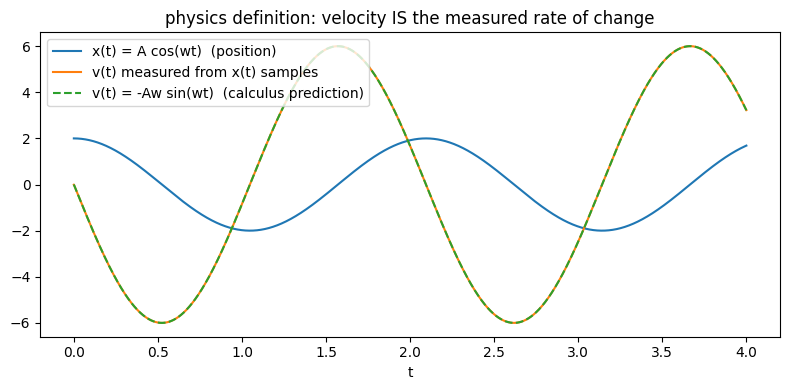

measured velocity vs calculus prediction, max error (interior points): 9.004e-06


In [3]:
A, omega = 2.0, 3.0
t = np.linspace(0, 4, 4000)
x_t = A * np.cos(omega * t)

v_numeric = velocity(x_t, t)          # the PHYSICS definition: rate of change of measured x(t)
v_analytic = -A * omega * np.sin(omega * t)   # the calculus prediction

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(t, x_t, label="x(t) = A cos(wt)  (position)")
ax.plot(t, v_numeric, label="v(t) measured from x(t) samples")
ax.plot(t, v_analytic, '--', label="v(t) = -Aw sin(wt)  (calculus prediction)")
ax.set_xlabel("t"); ax.legend(); ax.set_title("physics definition: velocity IS the measured rate of change")
plt.tight_layout(); plt.show()

interior = slice(10, -10)
max_err = np.max(np.abs(v_numeric[interior] - v_analytic[interior]))
print(f"measured velocity vs calculus prediction, max error (interior points): {max_err:.3e}")
assert max_err < 1e-3

## 3. The computer definition: what a machine actually has to do

A computer has no symbolic $\cos(x)$ unless it's told the rule, and it
cannot literally take $h\to0$. Two real strategies:

**(a) Finite differences** -- pick a small but FINITE $h$. There's a
genuine trade-off: too large and truncation error dominates (the secant
line is a bad approximation to the tangent); too small and FLOATING-POINT
ROUNDOFF dominates (subtracting two nearly-equal floats destroys precision).
The error curve is U-shaped, not monotonic.

**(b) Automatic differentiation** -- carry a value AND its derivative
through every operation using dual numbers $a+b\varepsilon$ (with
$\varepsilon^2=0$), so the chain rule applies mechanically and EXACTLY.
No $h$, no truncation, no roundoff trade-off -- this is what PyTorch/
TensorFlow actually do under the hood (`dgs.dual_autodiff` is the same
idea, done by hand, no torch needed).

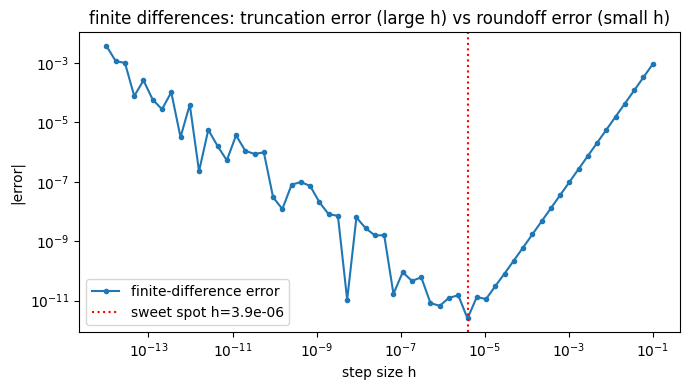

finite-difference sweet spot:  h=3.92e-06, error=2.50e-12
h too small (1e-14): error=3.71e-03  <- roundoff dominates
h too big   (1e-01): error=9.00e-04  <- truncation dominates

autodiff (dual number) derivative: 0.540302305868140
exact cos(x0):                     0.540302305868140
autodiff error: 0.00e+00  <- exactly zero, no h anywhere


In [4]:
hs = np.logspace(-1, -14, 60)
errors = ad.finite_difference_error_sweep(np.sin, np.cos, x0, hs)

fig, ax = plt.subplots(figsize=(7, 4))
ax.loglog(hs, errors, 'o-', markersize=3, label="finite-difference error")
best_idx = np.argmin(errors)
ax.axvline(hs[best_idx], color='r', linestyle=':', label=f"sweet spot h={hs[best_idx]:.1e}")
ax.set_xlabel("step size h"); ax.set_ylabel("|error|"); ax.legend()
ax.set_title("finite differences: truncation error (large h) vs roundoff error (small h)")
plt.tight_layout(); plt.show()

print(f"finite-difference sweet spot:  h={hs[best_idx]:.2e}, error={errors[best_idx]:.2e}")
print(f"h too small ({hs[-1]:.0e}): error={errors[-1]:.2e}  <- roundoff dominates")
print(f"h too big   ({hs[0]:.0e}): error={errors[0]:.2e}  <- truncation dominates")

val_ad, deriv_ad = ad.autodiff_derivative(ad.dsin, x0)
print(f"\nautodiff (dual number) derivative: {deriv_ad:.15f}")
print(f"exact cos(x0):                     {np.cos(x0):.15f}")
print(f"autodiff error: {abs(deriv_ad - np.cos(x0)):.2e}  <- exactly zero, no h anywhere")
assert deriv_ad == np.cos(x0) or abs(deriv_ad - np.cos(x0)) < 1e-14

## All three, side by side

| Definition | What it actually is | Result for f(x)=sin(x) at x=1 |
|---|---|---|
| Math (limit)      | an idealized limit, proved via a trig identity | exactly $\cos(1)$ |
| Physics (measured) | rate of change of a real sampled signal | matches calculus to $<10^{-3}$ (sampling-limited) |
| Computer (finite-diff) | approximate, with a real $h$ sweet spot | best case $\sim10^{-12}$, degrades both directions |
| Computer (autodiff) | exact chain-rule bookkeeping, no $h$ | exactly $\cos(1)$, same as the math limit |

The math definition and the autodiff definition agree EXACTLY -- because
autodiff isn't approximating the limit, it's mechanizing the same chain
rule the limit proof used. Finite differences and physical measurement are
the two that are genuinely approximate, for different reasons (step-size
trade-off vs. measurement/sampling limits).